<a href="https://colab.research.google.com/github/Imran1hp/Deep-Learning-/blob/main/Py_Torch_workflowipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas
import torch
from torch import nn ## for neural network building block
import numpy as np
import matplotlib.pyplot as plt

In [2]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step =0.02
X = torch.arange(start ,end,step ).unsqueeze(dim=1)
Y = weight * X + bias

In [3]:
X[:10],Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X) ,len(Y)

(50, 50)

In [5]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train , Y_train = X[:train_split] , Y[:train_split]
X_test , Y_test = X[train_split:] , Y[train_split:]

In [6]:
len(X_train),len(Y_train),len(X_test),len(Y_test)

(40, 40, 10, 10)

/tmp/ipython-input-622729106.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend (prop={"size":14})


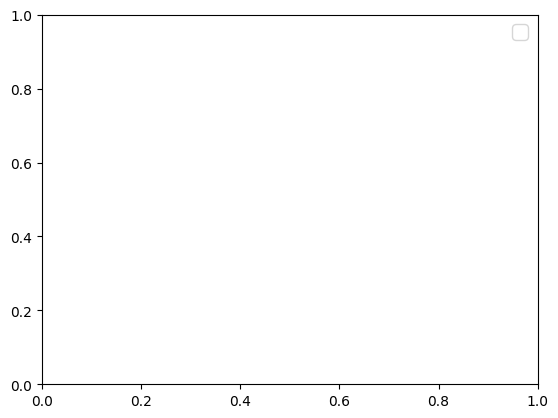

In [7]:
def  plot_prediction (train_data = X_train,train_labels =Y_train,
                      test_data = X_test, test_labels=Y_test,prediction =None):
  plt.figure(figsize=(10,7))

  plt.scatter(train_data , train_labels , c="y" , s= 4 ,label = "Training data")

  plt.scatter(test_data , test_labels , c='g',s=4 , label ="Testing data ")

  if prediction is not None:
    plt.scatter(test_data , prediction , c='r', s=4 ,label ="Predictions")
plt.legend (prop={"size":14})

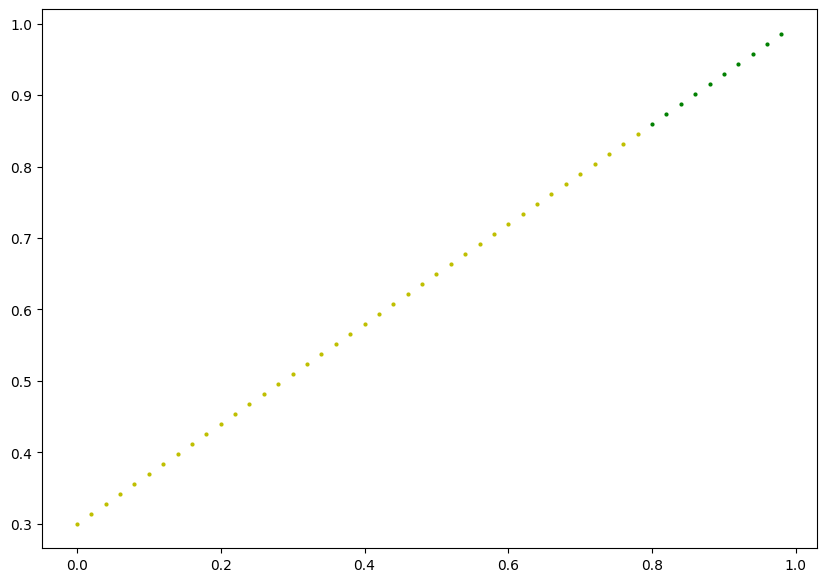

In [8]:
plot_prediction()

##Bluid a model


In [9]:
from torch import nn
class LinearRegressionModel(nn.Module): #<- almost everything there inherhites from nn.module

    def __init__ (self):
      super().__init__()
      self.weights = nn.Parameter(torch.randn(1, requires_grad=True ,dtype=float))

      self.bias = nn.Parameter(torch.randn(1 ,requires_grad=True , dtype=float))

## Forword method to define the computation in the model
    def forward (self ,x:torch.Tensor) -> torch.Tensor: # x is the input data
      return self.weights * x + self.bias  # this is the linear regression formula


##checking the content of our pytorch model

In [10]:
# Create a random seed
torch.manual_seed(42)

model_0 = LinearRegressionModel()
model_0
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], dtype=torch.float64, requires_grad=True),
 Parameter containing:
 tensor([0.1288], dtype=torch.float64, requires_grad=True)]

In [11]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367], dtype=torch.float64)),
             ('bias', tensor([0.1288], dtype=torch.float64))])

## MAKING PREDICTION WITH OUR MODEL

In [12]:
with torch.inference_mode():
  y_preds = model_0(X_test)

  print(y_preds)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], dtype=torch.float64)


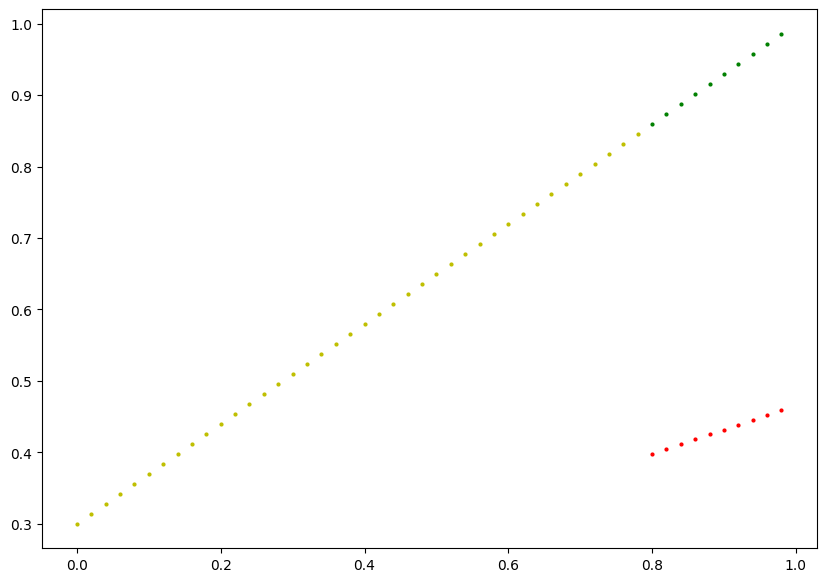

In [13]:
plot_prediction(prediction=y_preds)

##LOST FUNCTION
Loss function: A function to measure how wrong your model's prediction are to the ideal outputs.

Optimizer: Takes into account the loss od a model and adject the model's parameters

In [14]:
# we use MAE loss function

loss_fn= nn.L1Loss()

#Setup an optimizer (SGD)

optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

### Bluiding a training loop and a tedting loop in Pytorch


In [15]:
# AN epoch is one loop through the data
epochs =100
epoch_count=[]
loss_values=[]
test_loss_values=[]





for epoch in range(epochs):
  model_0.train() ## train mode in pyorch sets all the required gradients to required gradents


  # Forward pass
  y_preds = model_0(X_train)


  # calculate the loss function
  loss = loss_fn(y_preds , Y_train)
  print("loss: ", loss)

  # Optimizer zero grad
  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval() ## turns off the gradient required
  with torch.inference_mode():

   test_preds = model_0(X_test)
   test_loss = loss_fn(test_preds,Y_test)
  if epoch % 10 == 0 :
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)

    print(f"Epoch:{epoch} | loss: {loss} |  test loss: {test_loss}")
    print(model_0.state_dict())


loss:  tensor(0.3129, dtype=torch.float64, grad_fn=<MeanBackward0>)
Epoch:0 | loss: 0.31288135683755547 |  test loss: 0.4810651841540759
OrderedDict({'weights': tensor([0.3406], dtype=torch.float64), 'bias': tensor([0.1388], dtype=torch.float64)})
loss:  tensor(0.3014, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss:  tensor(0.2898, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss:  tensor(0.2783, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss:  tensor(0.2668, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss:  tensor(0.2553, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss:  tensor(0.2438, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss:  tensor(0.2322, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss:  tensor(0.2207, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss:  tensor(0.2092, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss:  tensor(0.1977, dtype=torch.float64, grad_fn=<MeanBackward0>)
Epoch:10 | loss: 0.1976713574739093 |  test loss: 0.346355184508239
Orde

In [16]:
import numpy as np
np.array(torch.tensor(loss_values).numpy()) , test_loss_values

/tmp/ipython-input-3058531962.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  np.array(torch.tensor(loss_values).numpy()) , test_loss_values


(array([0.31288136, 0.19767136, 0.08908721, 0.0531485 , 0.04543793,
        0.04167861, 0.03818929, 0.03476085, 0.03132381, 0.02788737]),
 [tensor(0.4811, dtype=torch.float64),
  tensor(0.3464, dtype=torch.float64),
  tensor(0.2173, dtype=torch.float64),
  tensor(0.1446, dtype=torch.float64),
  tensor(0.1136, dtype=torch.float64),
  tensor(0.0992, dtype=torch.float64),
  tensor(0.0889, dtype=torch.float64),
  tensor(0.0806, dtype=torch.float64),
  tensor(0.0723, dtype=torch.float64),
  tensor(0.0647, dtype=torch.float64)])

In [17]:
import numpy as np
np.array(torch.tensor(loss_values).numpy()) , test_loss_values

(array([0.31288136, 0.19767136, 0.08908721, 0.0531485 , 0.04543793,
        0.04167861, 0.03818929, 0.03476085, 0.03132381, 0.02788737]),
 [tensor(0.4811, dtype=torch.float64),
  tensor(0.3464, dtype=torch.float64),
  tensor(0.2173, dtype=torch.float64),
  tensor(0.1446, dtype=torch.float64),
  tensor(0.1136, dtype=torch.float64),
  tensor(0.0992, dtype=torch.float64),
  tensor(0.0889, dtype=torch.float64),
  tensor(0.0806, dtype=torch.float64),
  tensor(0.0723, dtype=torch.float64),
  tensor(0.0647, dtype=torch.float64)])

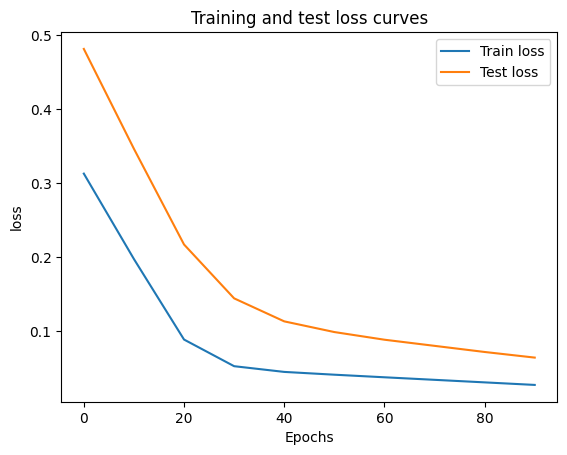

In [18]:
plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy())  , label ="Train loss")
plt.plot(epoch_count , test_loss_values , label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("loss")
plt.xlabel("Epochs")
plt.legend()

In [19]:
new_y_preds = model_0(X_test)

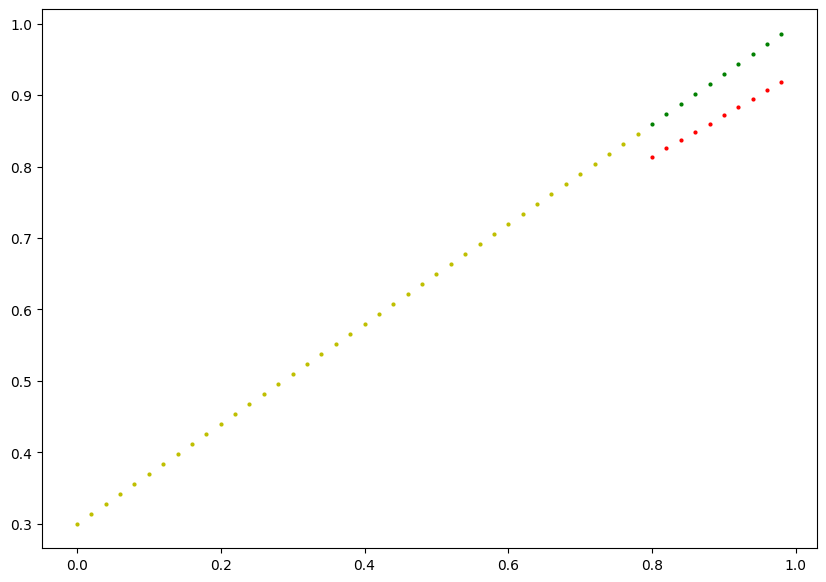

In [20]:
plot_prediction(prediction=new_y_preds.detach())

## Sving a model is Pytorch


In [24]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True , exist_ok =True)

MODEL_NAME = "01_pytorch_workflow_model_0.pth"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

print(f"Saving model to:{MODEL_SAVE_PATH}")

torch.save(obj = model_0.state_dict(),f=MODEL_SAVE_PATH)

Saving model to:models/01_pytorch_workflow_model_0.pth


### 1. Mount Google Drive

First, you need to mount your Google Drive to make it accessible within your Colab environment. This will prompt you to authenticate your Google account.

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Save a file to Google Drive

Once your Drive is mounted, you can save any file to a specified path within your Drive. For example, let's save the trained model from the previous steps to a new folder in your Google Drive.

In [26]:
import torch
from pathlib import Path

# Define the path to save the model in Google Drive
DRIVE_PATH = Path('/content/drive/MyDrive/colab_saved_models')
DRIVE_PATH.mkdir(parents=True, exist_ok=True)

# Use the same model name as before or choose a new one
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH_DRIVE = DRIVE_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH_DRIVE}")

# Save the model's state_dict to Google Drive
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH_DRIVE)

Saving model to: /content/drive/MyDrive/colab_saved_models/01_pytorch_workflow_model_0.pth
